<a href="https://colab.research.google.com/github/jonathanordrick/2025_Pengolahan_Citra_TI2B/blob/main/Minggu03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

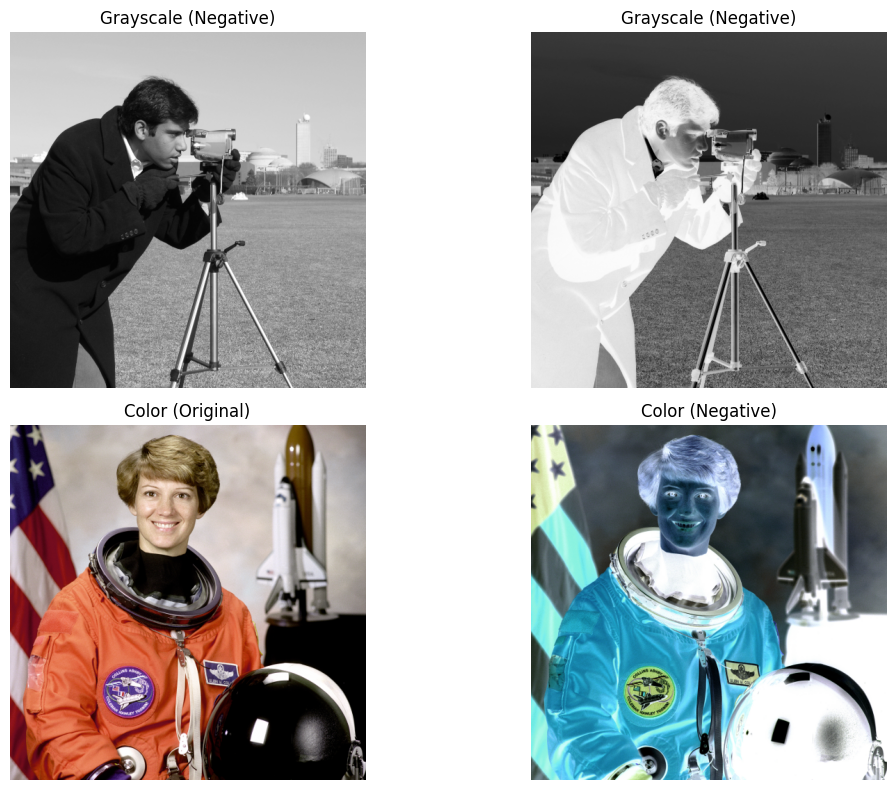

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# Transormasi negatif citra grayscale
image_gray_uint8 = data.camera() # Citra grayscale (512x512, 0..255) 09:
image_gray_float = img_as_float(image_gray_uint8) # Konversi ke float

negative_gray = 1.0 - image_gray_float # Inversi Intensitas:

# Transformasi negatif citra berwarna
image_color_uint8 = data.astronaut()
image_color_float = img_as_float(image_color_uint8)

negative_color = 1.0 - image_color_float

# Plotting hasil
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Negative)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

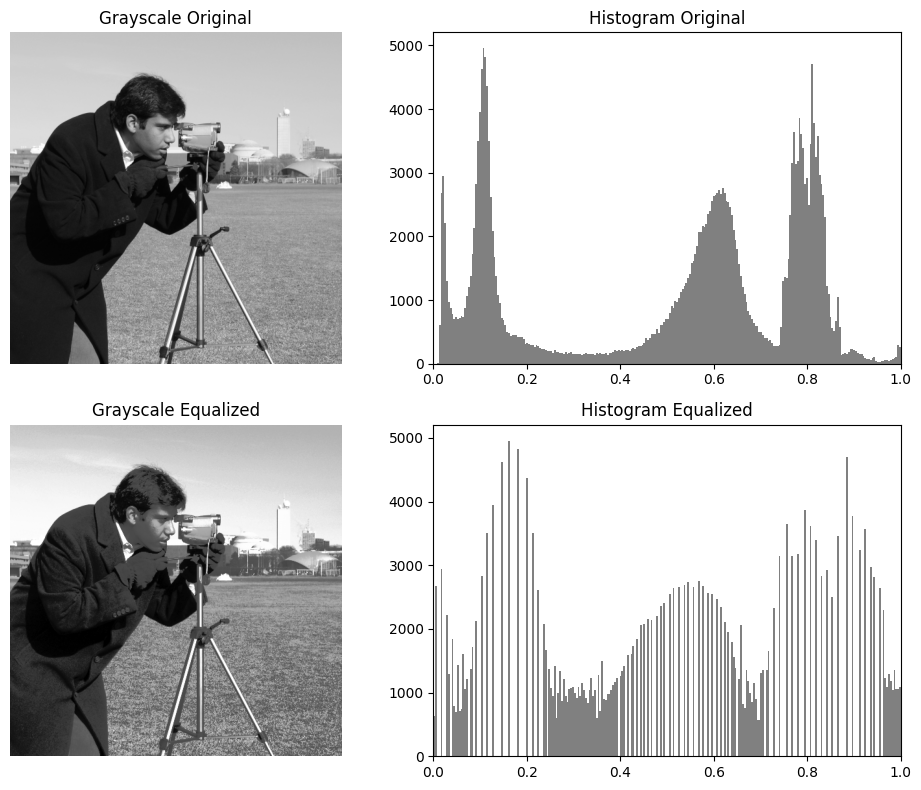

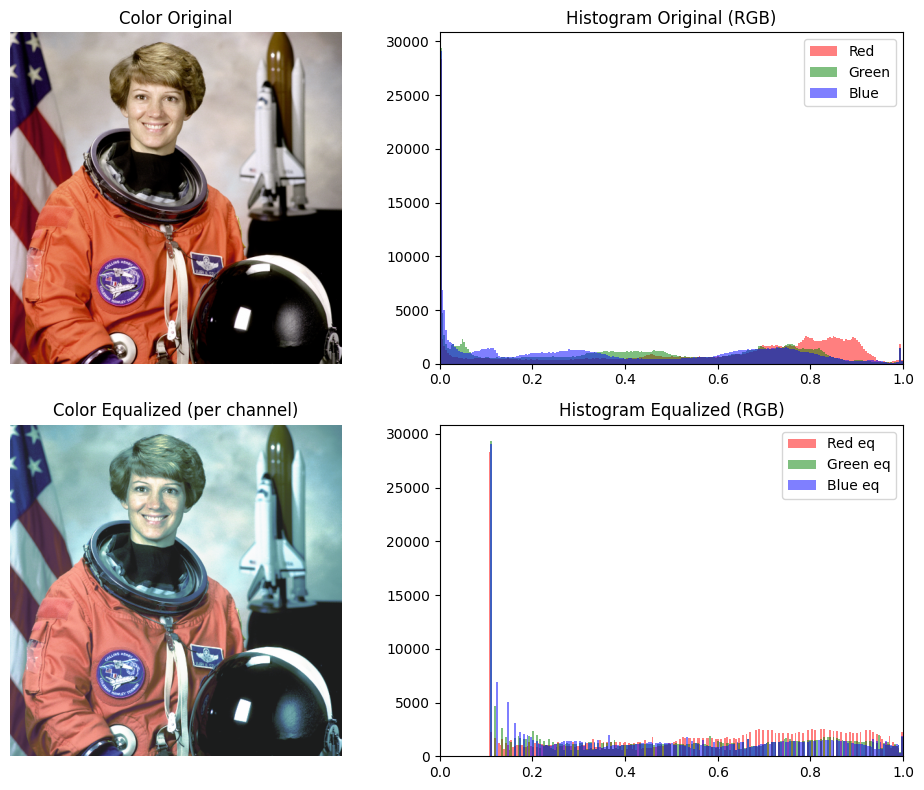

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# -----------------------------------------------------
# BAGIAN 1: HISTOGRAM & EKUALISASI HISTOGRAM (GRAYSCALE)
# -----------------------------------------------------

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera()  # sudah grayscale (uint8, 0..255)
image_gray = img_as_float(image_gray_uint8)  # konversi ke float [0..1]

# 2. Menghitung histogram citra asli (dengan numpy.histogram)
# Kita perbesar bins=256 untuk melihat distribusi piksel
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram
# Dengan skimage.exposure.equalize_hist, hasil di rentang [0..1]
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot grayscale: citra asli & histogram, citra ekualisasi & histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli Grayscale
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Citra Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0, 1)

# (c) Citra Hasil Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Citra Hasil Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# BAGIAN 2: HISTOGRAM & EKUALISASI HISTOGRAM (CITRA WARNA)
# -------------------------------------------------------

# 1. Memuat citra berwarna
image_color_uint8 = data.astronaut()  # citra berwarna RGB (uint8)
image_color = img_as_float(image_color_uint8)  # konversi ke float [0..1]

# 2. Histogram gabungan (semua kanal) atau per kanal
# Di sini kita tampilkan histogram gabungan R, G, B untuk citra asli.
r_channel = image_color[:, :, 0]
g_channel = image_color[:, :, 1]
b_channel = image_color[:, :, 2]

# Hitung histogram untuk tiap kanal, 256 bins
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0, 1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0, 1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram tiap kanal secara independen
# (Catatan: cara ini bisa mengubah keseimbangan warna.
# Terkadang lebih baik melakukan ekualisasi hanya pada kanal luminance (Y)
# atau Value (HSV). Tapi di sini kita tunjukkan contoh per kanal.)
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

# Gabungkan kembali menjadi citra RGB yang sudah di-ekualisasi
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Hitung histogram citra berwarna ekualisasi (tiap kanal)
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0, 1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0, 1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot citra berwarna & histogram
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli (Color)
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# (b) Histogram Asli (tumpuk R, G, B)
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0, 1)
axes2[0, 1].legend(loc='upper right')

# (c) Citra Hasil Ekualisasi (RGB)
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

# (d) Histogram Ekualisasi (tumpuk R, G, B)
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0, 1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


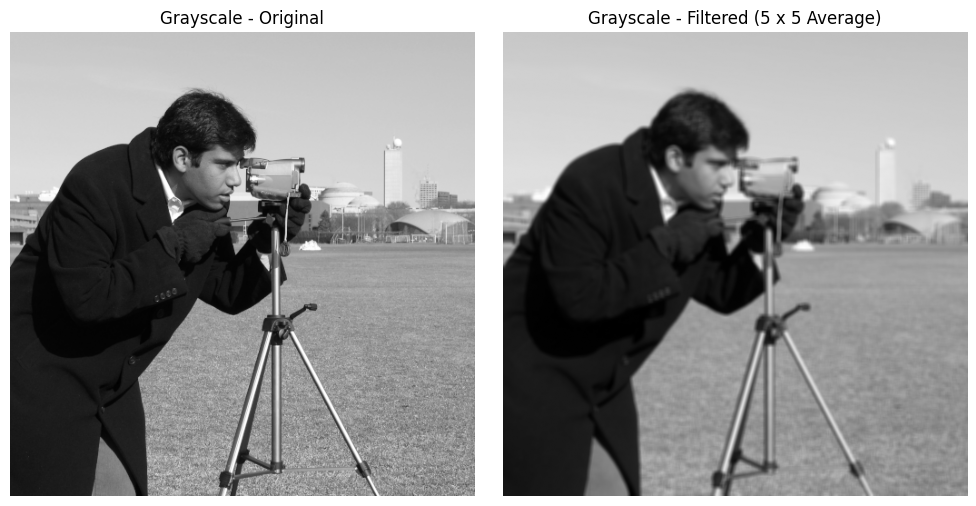

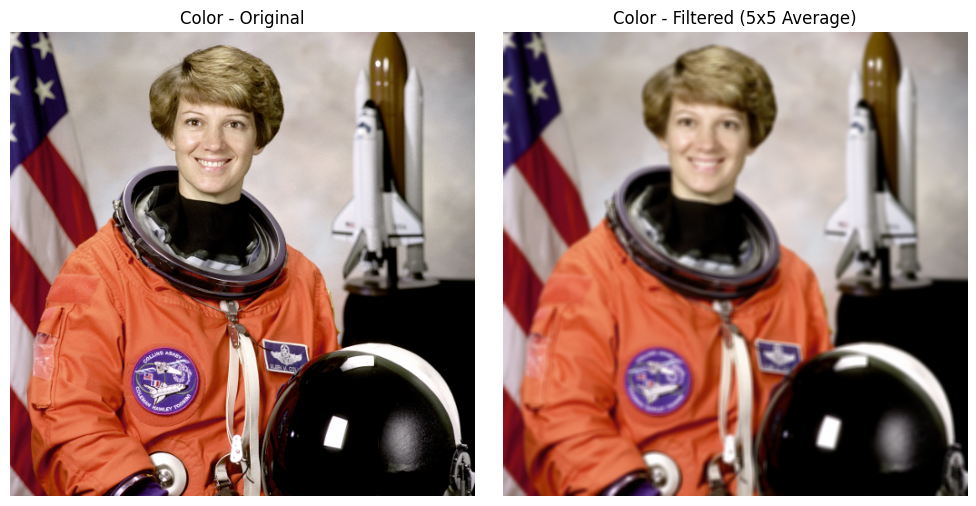

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
# A. MEMUAT CITRA GRAYSCALE (CAMERA)

gray_uint8 = data.camera() # range 0..255
gray_img = img_as_float(gray_uint8) # Konversi menjadi float
gray_img = img_as_float(gray_uint8)

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Menerapkan filter median
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size} x {kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 2) FILTER RATA-RATA PADA CITRA BERWARNA

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut()
color_img = img_as_float(color_uint8)
# B. Kita akan terapkan filter rata-rata pada tiap kanal R, G, B
# secara terpisah, lalu gabungkan
color_filtered = np.zeros_like(color_img)

for c in range(3): # c = 0 (Red), 1 (Green), 2 (Blue)
  channel_original = color_img[:, :, c]
  channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
  color_filtered[:, :, c] = channel_filtered

# C. Tampilkan Hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()



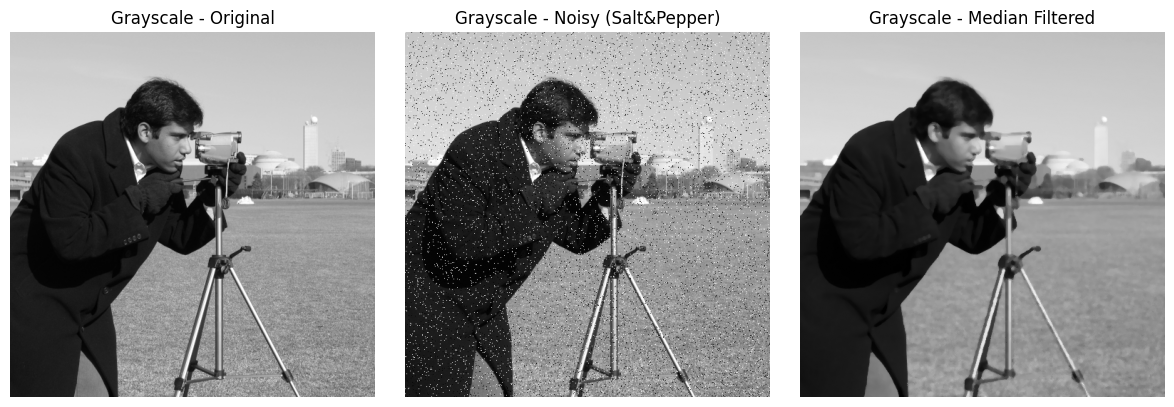

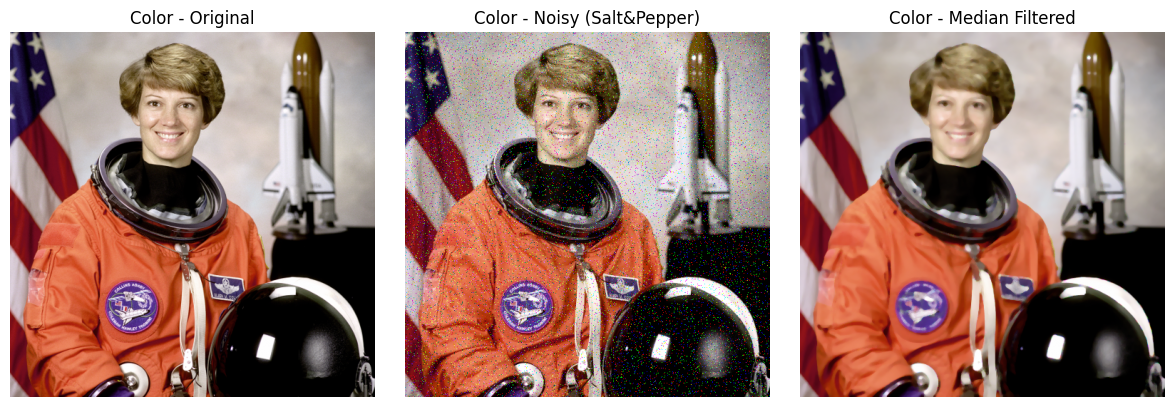

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# FILTER MEDIAN PADA CITRA GRAYSCALE
# A. Memuat citra grayscale (contoh: 'camera')
gray_uint8 = data.camera()
gray_float = img_as_float(gray_uint8)

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)
# Amount = 0.05 berarti 5% piksel terpengaruh noise

# C. Menerapkan filter median
# Kita gunakan structuring element berbentuk disk radius 3
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Plot hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# FILTER MEDIAN PADA CITRA BERWARNA
# A. Memuat citra berwarna (contoh: 'astronaut')
color_uint8 = data.astronaut()
color_float = img_as_float(color_uint8)

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median
# Pada scikit-image 0.19+, median() mampu menangani array 3D (RGB),
# atau kita bisa memanggil per kanal. Di sini langsung:
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
  color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Plot hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()

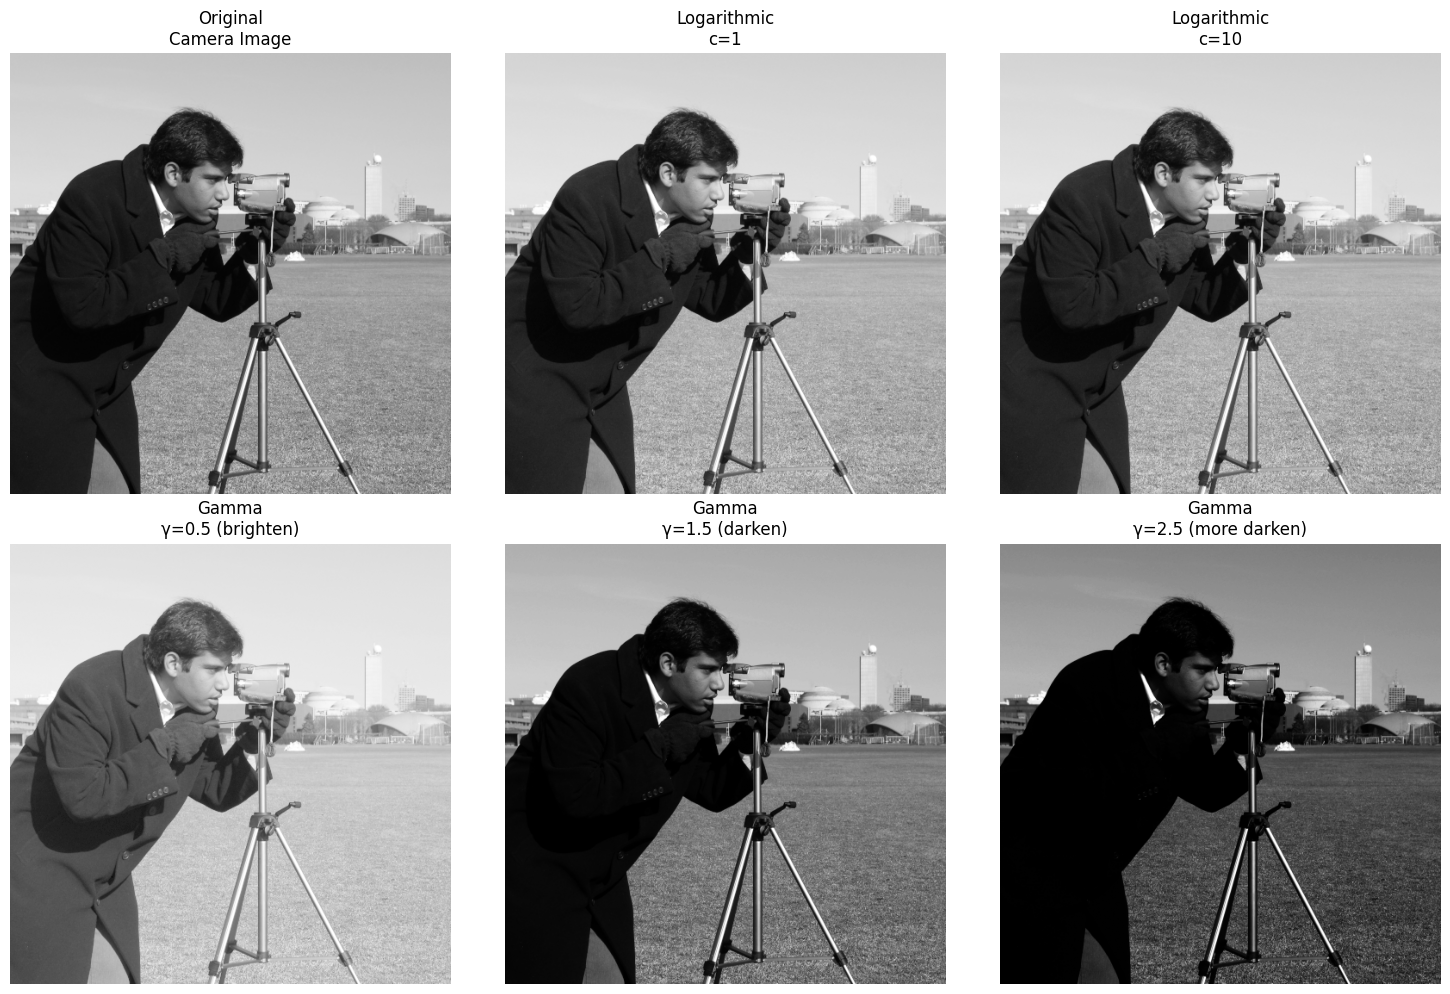

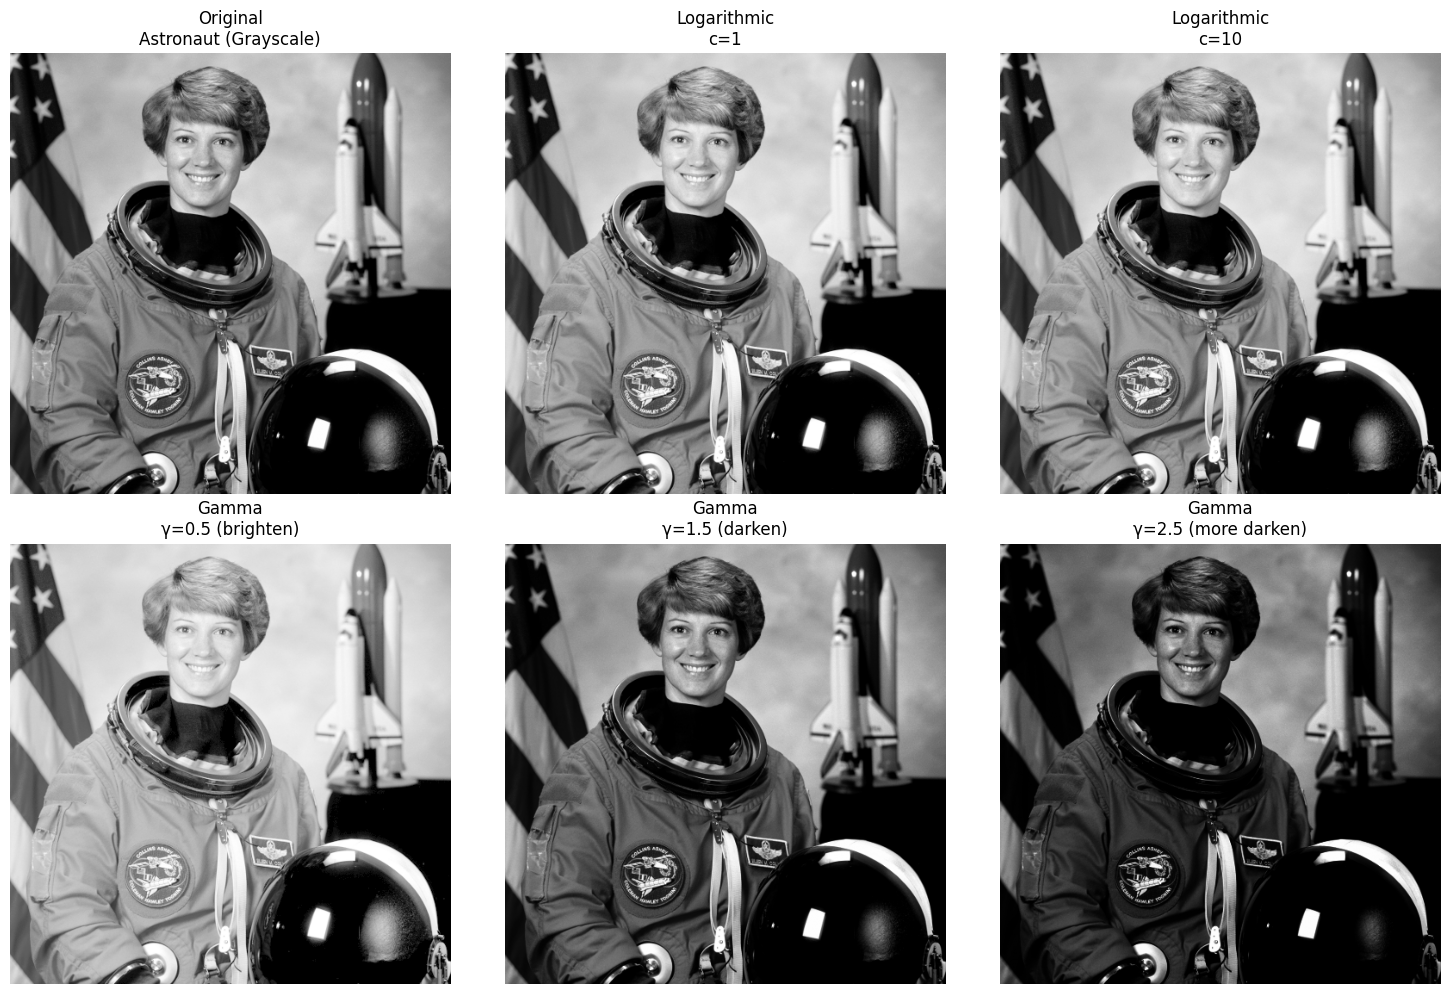

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, img_as_float
from skimage.exposure import adjust_gamma, adjust_log

# Memuat citra
gray_image1 = img_as_float(data.camera())  # Sudah grayscale
gray_image2 = color.rgb2gray(img_as_float(data.astronaut()))  # Konversi ke grayscale

# Fungsi untuk plot hasil transformasi
def plot_transforms(original, title):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Original
    axes[0,0].imshow(original, cmap='gray')
    axes[0,0].set_title(f"Original\n{title}")
    axes[0,0].axis('off')

    # Transformasi Logaritmik dengan c berbeda
    log1 = adjust_log(original, gain=1)
    axes[0,1].imshow(log1, cmap='gray')
    axes[0,1].set_title("Logarithmic\nc=1")
    axes[0,1].axis('off')

    log2 = adjust_log(original, gain=10)
    axes[0,2].imshow(log2, cmap='gray')
    axes[0,2].set_title("Logarithmic\nc=10")
    axes[0,2].axis('off')

    # Transformasi Gamma dengan gamma berbeda
    gamma1 = adjust_gamma(original, gamma=0.5)
    axes[1,0].imshow(gamma1, cmap='gray')
    axes[1,0].set_title("Gamma\nγ=0.5 (brighten)")
    axes[1,0].axis('off')

    gamma2 = adjust_gamma(original, gamma=1.5)
    axes[1,1].imshow(gamma2, cmap='gray')
    axes[1,1].set_title("Gamma\nγ=1.5 (darken)")
    axes[1,1].axis('off')

    gamma3 = adjust_gamma(original, gamma=2.5)
    axes[1,2].imshow(gamma3, cmap='gray')
    axes[1,2].set_title("Gamma\nγ=2.5 (more darken)")
    axes[1,2].axis('off')

    plt.tight_layout()
    plt.show()

# Plot untuk kedua citra
plot_transforms(gray_image1, "Camera Image")
plot_transforms(gray_image2, "Astronaut (Grayscale)")

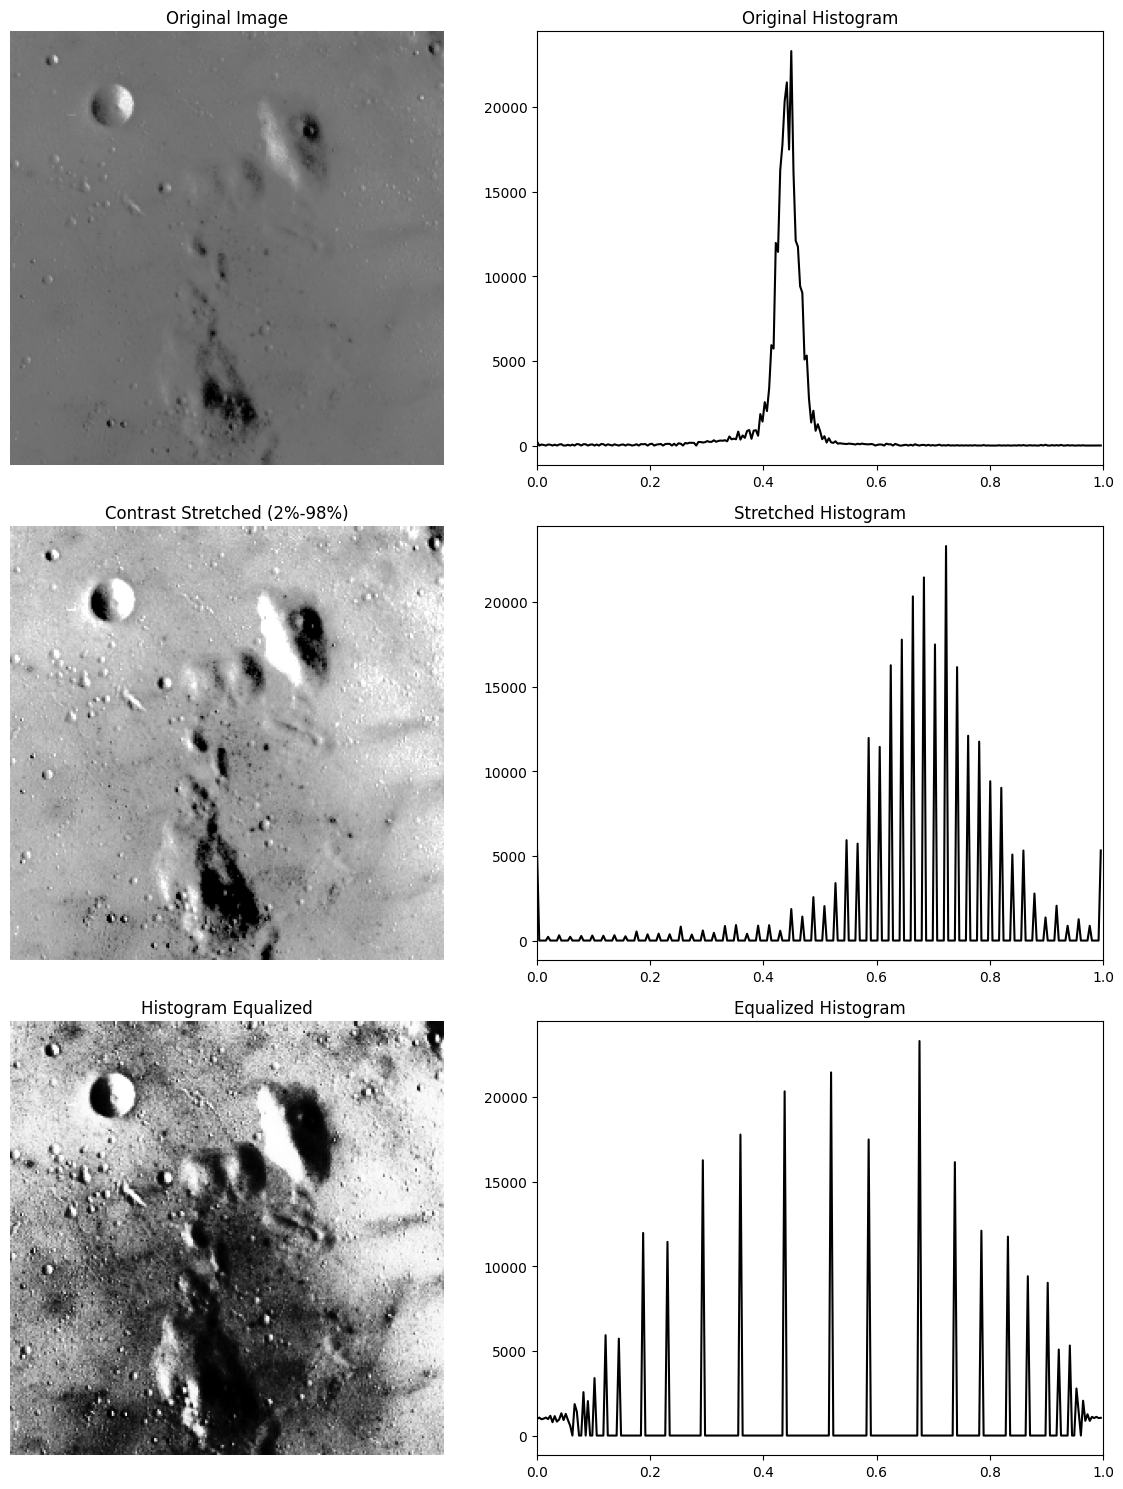

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# Memuat citra dengan kontras rendah
image = img_as_float(data.moon())  # Citra bulan memiliki kontras rendah

# 1. Contrast Stretching
# Tentukan range intensitas yang diinginkan (2% dan 98% percentil)
p2, p98 = np.percentile(image, (2, 98))
image_stretched = exposure.rescale_intensity(image, in_range=(p2, p98))

# 2. Histogram Equalization
image_equalized = exposure.equalize_hist(image)

# Hitung histogram untuk ketiga citra
hist_original, bins_original = np.histogram(image.ravel(), bins=256, range=(0, 1))
hist_stretched, bins_stretched = np.histogram(image_stretched.ravel(), bins=256, range=(0, 1))
hist_equalized, bins_equalized = np.histogram(image_equalized.ravel(), bins=256, range=(0, 1))

# Plot hasil
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

# Baris 1: Citra Asli
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].plot(bins_original[:-1], hist_original, color='black')
axes[0, 1].set_title("Original Histogram")
axes[0, 1].set_xlim(0, 1)

# Baris 2: Contrast Stretched
axes[1, 0].imshow(image_stretched, cmap='gray')
axes[1, 0].set_title("Contrast Stretched (2%-98%)")
axes[1, 0].axis('off')

axes[1, 1].plot(bins_stretched[:-1], hist_stretched, color='black')
axes[1, 1].set_title("Stretched Histogram")
axes[1, 1].set_xlim(0, 1)

# Baris 3: Histogram Equalized
axes[2, 0].imshow(image_equalized, cmap='gray')
axes[2, 0].set_title("Histogram Equalized")
axes[2, 0].axis('off')

axes[2, 1].plot(bins_equalized[:-1], hist_equalized, color='black')
axes[2, 1].set_title("Equalized Histogram")
axes[2, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

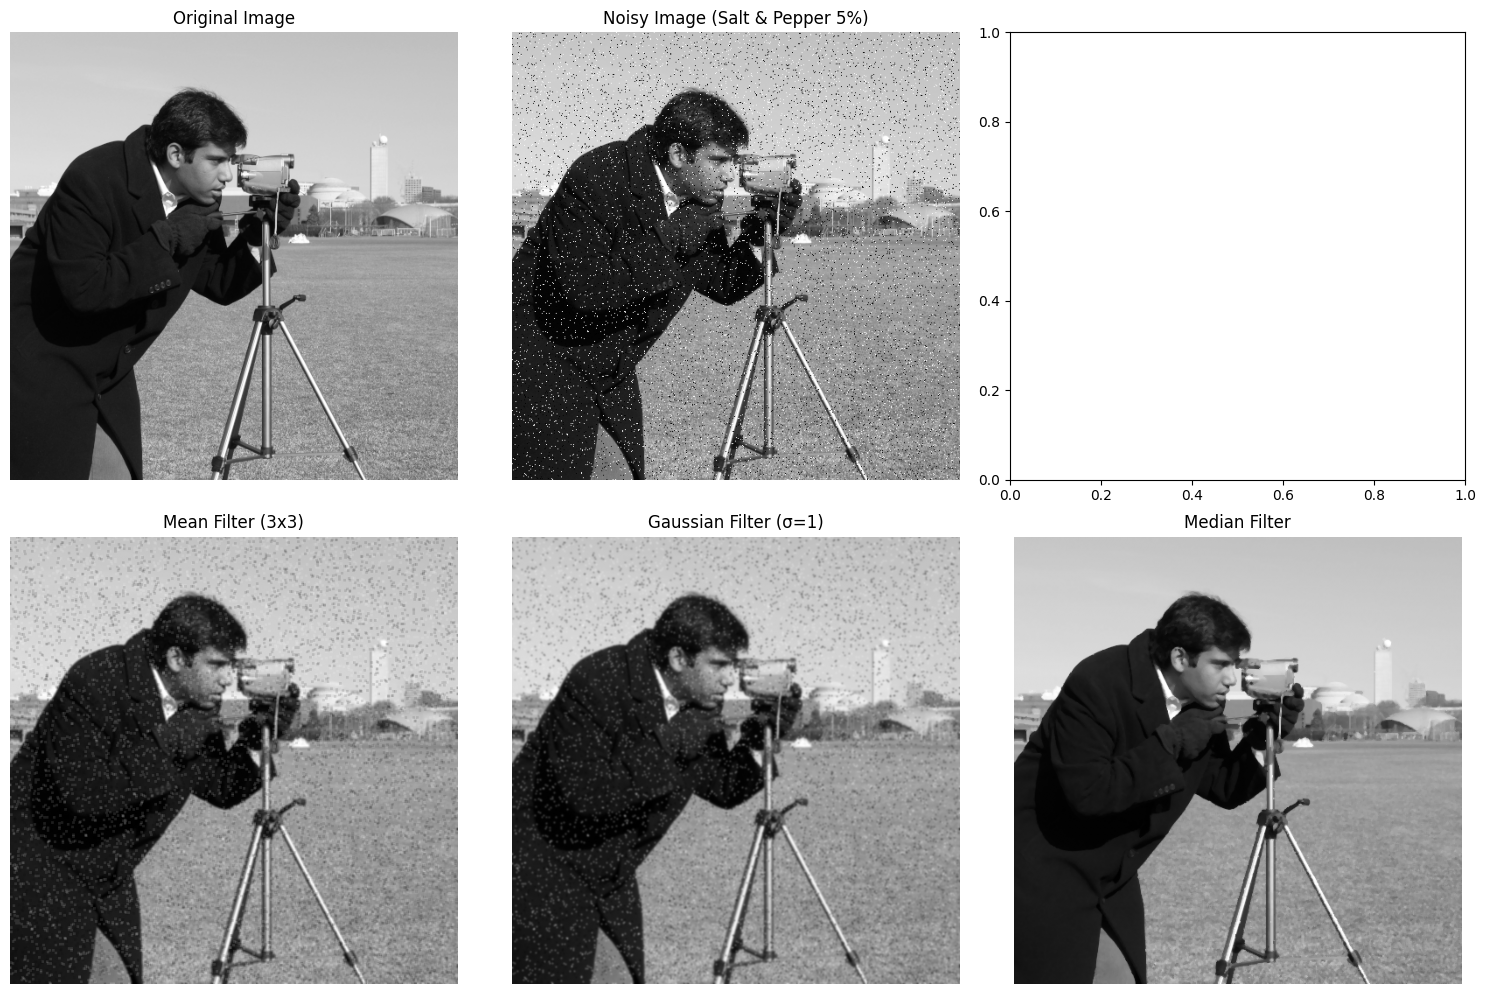

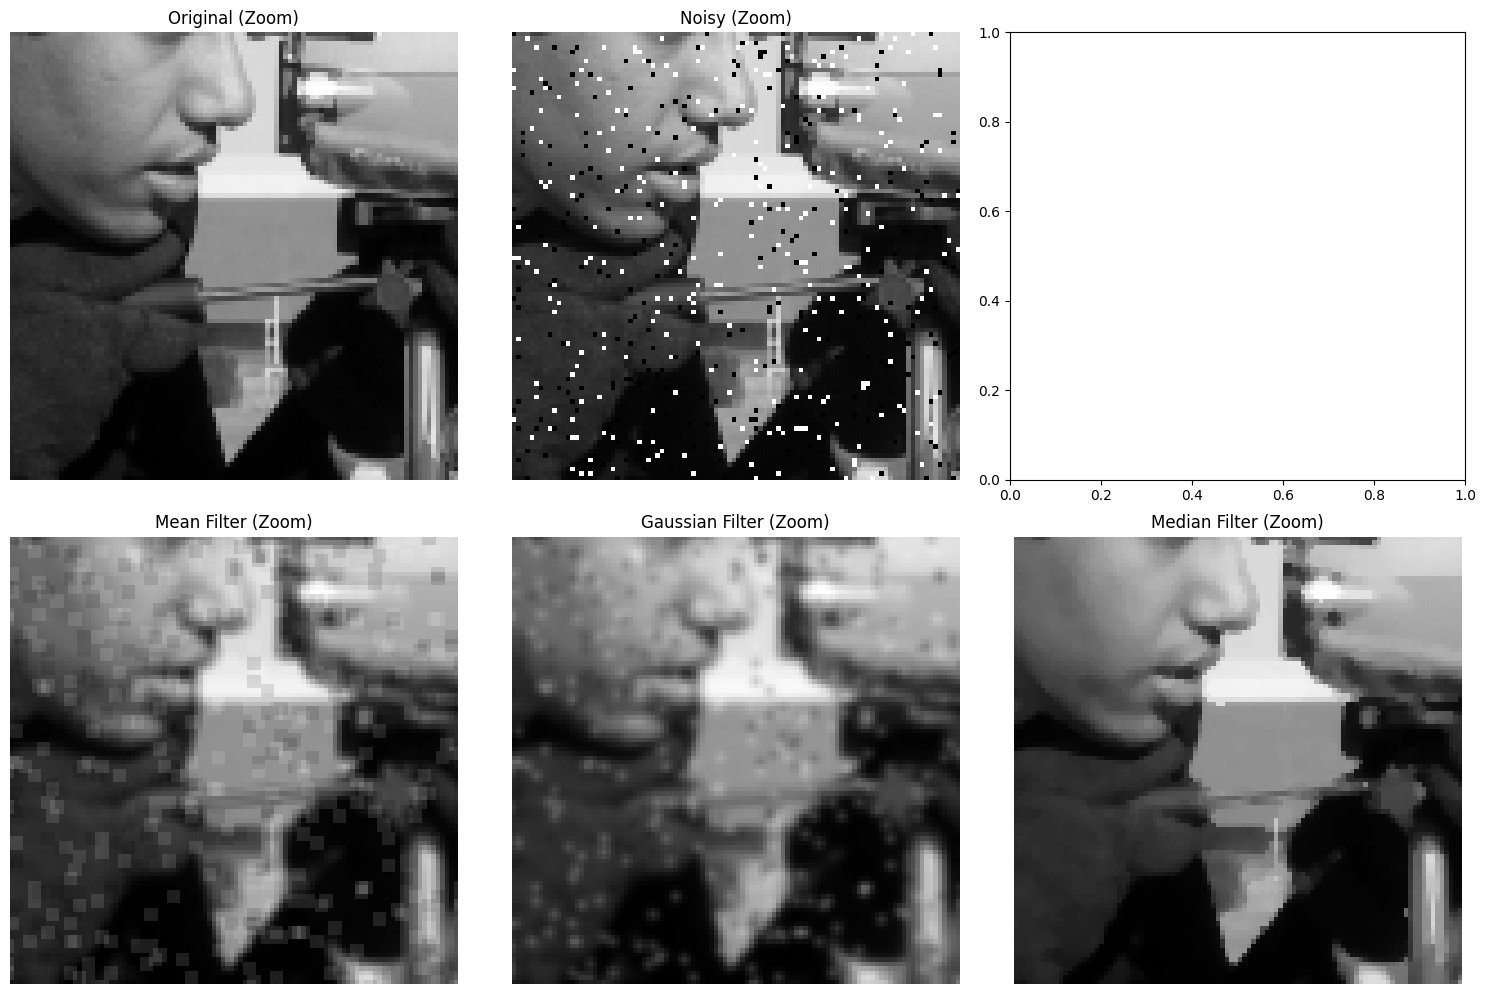

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, img_as_float
from scipy import ndimage

# Memuat citra grayscale
original_image = img_as_float(data.camera())

# Menambahkan noise salt-and-pepper (5%)
noisy_image = util.random_noise(original_image, mode='s&p', amount=0.05)

# 1. Filter Rata-rata (Mean Filter)
# Membuat kernel rata-rata 3x3
kernel_size = 3
mean_kernel = np.ones((kernel_size, kernel_size)) / (kernel_size ** 2)
mean_filtered = ndimage.convolve(noisy_image, mean_kernel, mode='reflect')

# 2. Filter Gaussian (sebagai perbandingan tambahan)
gaussian_filtered = filters.gaussian(noisy_image, sigma=1)

# 3. Filter Median
median_filtered = filters.median(noisy_image, behavior='ndimage')

# Plot hasil
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Baris 1: Citra asli dan noisy
axes[0, 0].imshow(original_image, cmap='gray')
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy_image, cmap='gray')
axes[0, 1].set_title("Noisy Image (Salt & Pepper 5%)")
axes[0, 1].axis('off')

# Baris 2: Hasil filtering
axes[1, 0].imshow(mean_filtered, cmap='gray')
axes[1, 0].set_title("Mean Filter (3x3)")
axes[1, 0].axis('off')

axes[1, 1].imshow(gaussian_filtered, cmap='gray')
axes[1, 1].set_title("Gaussian Filter (σ=1)")
axes[1, 1].axis('off')

axes[1, 2].imshow(median_filtered, cmap='gray')
axes[1, 2].set_title("Median Filter")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Zoom pada area tertentu untuk melihat detail tepi
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
zoom_area = (slice(150, 250), slice(200, 300))  # Area untuk zoom

# Baris 1: Citra asli dan noisy (zoom)
axes2[0, 0].imshow(original_image[zoom_area], cmap='gray')
axes2[0, 0].set_title("Original (Zoom)")
axes2[0, 0].axis('off')

axes2[0, 1].imshow(noisy_image[zoom_area], cmap='gray')
axes2[0, 1].set_title("Noisy (Zoom)")
axes2[0, 1].axis('off')

# Baris 2: Hasil filtering (zoom)
axes2[1, 0].imshow(mean_filtered[zoom_area], cmap='gray')
axes2[1, 0].set_title("Mean Filter (Zoom)")
axes2[1, 0].axis('off')

axes2[1, 1].imshow(gaussian_filtered[zoom_area], cmap='gray')
axes2[1, 1].set_title("Gaussian Filter (Zoom)")
axes2[1, 1].axis('off')

axes2[1, 2].imshow(median_filtered[zoom_area], cmap='gray')
axes2[1, 2].set_title("Median Filter (Zoom)")
axes2[1, 2].axis('off')

plt.tight_layout()
plt.show()